In [1]:
"""
GRU Flood Forecasting Model
Predicts streamflow 24 hours ahead using the top30 high flood-severity sites.
"""
import torch
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from src.preprocessing.preprocessing import processor
from src.models.gru import GRUModel
from src.utils.helpers import create_sequences

STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

TARGET = "streamflow_cfs_mean" 

WINDOW_SIZE = 72

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "file_path": "flood-dataset-top30",
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

In [2]:
pcr = processor(config)
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.8 (193.6MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,278 | Val: 341,318 | Test: 341,219
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06308500"
	"06803495"
	"06700000"
	"06447500"
	"06821500"
	…
	"06061500"
	"06036650"
	"06803513"
	"06211000"
	"06935755"
]
(4818417, 31)


In [3]:
print("Creating sequences...")
X_train, y_train, train_site_ids = create_sequences(train_X, train_y, WINDOW_SIZE)
X_val, y_val, val_site_ids = create_sequences(val_X, val_y, WINDOW_SIZE)
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print("Sequences created.")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Creating sequences...
Sequences created.
Train: (2727758, 72, 28), Val: (338798, 72, 28), Test: (338699, 72, 28)


In [4]:
gru = GRUModel(
    gru_units=(32, 16),
    dense_units=64,
    dropout_rate=0.3,
    under_predict_penalty=2,
    learning_rate=1e-3,
)

gru.build(input_shape=(WINDOW_SIZE, X_train.shape[2]))
gru.summary()

# %%
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

gru.fit(
    (X_train, y_train),
    val_ds=(X_val, y_val),
    epochs=50,
    callbacks=[early_stopping],
    batch_size=32,
)

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 72, 32)         │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,505 (37.13 KB)

 Trainable params: 9,505 (37.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1520s 18ms/step - loss: 0.4899 - mae: 0.1981 - val_loss: 0.5627 - val_mae: 0.1951
Epoch 2/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1031s 12ms/step - loss: 0.4536 - mae: 0.1828 - val_loss: 0.6086 - val_mae: 0.1951
Epoch 3/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1038s 12ms/step - loss: 0.4379 - mae: 0.1807 - val_loss: 0.6212 - val_mae: 0.2022
Epoch 4/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1040s 12ms/step - loss: 0.4318 - mae: 0.1802 - val_loss: 0.6349 - val_mae: 0.1873
Epoch 5/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1040s 12ms/step - loss: 0.4497 - mae: 0.1875 - val_loss: 0.6656 - val_mae: 0.1904
Epoch 6/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1042s 12ms/step - loss: 0.4986 - mae: 0.1985 - val_loss: 0.6480 - val_mae: 0.2063


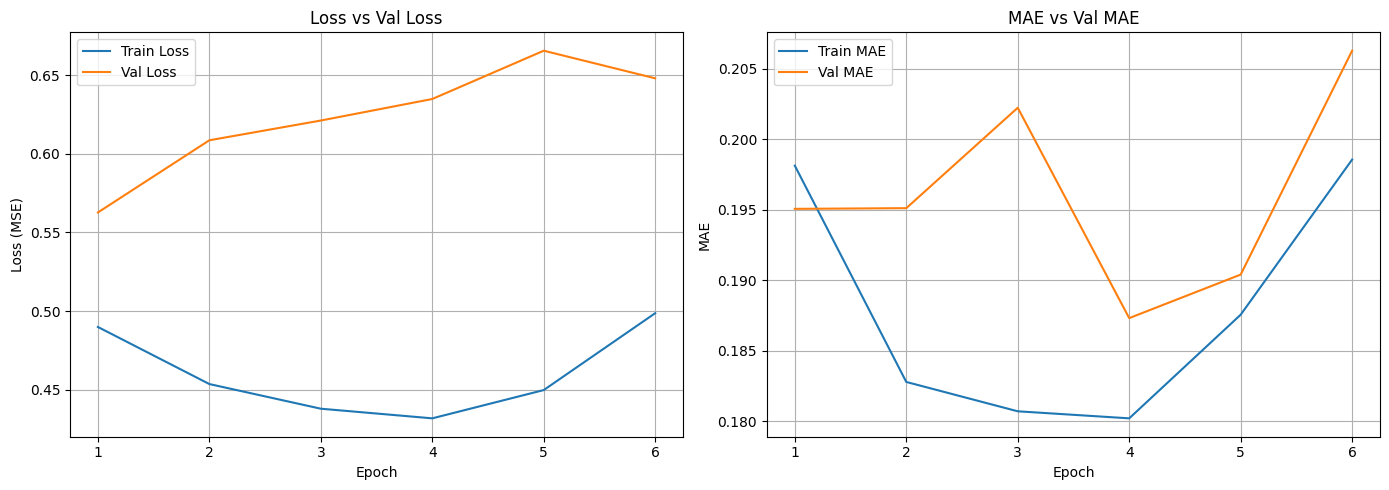

In [5]:
gru.plot_training_history()

In [6]:
gru.evaluate(X_test, y_test)

Test loss: 0.5519  |  MAE (scaled): 0.1944


In [7]:
gru.save_model(name="gru_model_2xloss")

WindowsPath('C:/Users/sacha/RiceLocal/Capstone/Coding/Flood-Forecasting/src/models/trained_models/gru_model_2xloss.keras/gru_model_2xloss.keras')

In [9]:
pcr.save(path="gru_model_2xloss.pkl")

Preprocessor saved to gru_model_2xloss.pkl
